# 05. Analytics - Pandas

## 05.1. Importação das bibliotecas

### 05.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys

### 05.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

### 05.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 05.2. Visão geral dos dados

### 05.2.1. Habilitando a exibição de todas as colunas

In [4]:
pd.set_option('display.max_columns', None)

### 05.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLEAN_PANDAS)

### 05.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(440832, 11)

### 05.2.4. Exibindo o dataset

In [7]:
df.head(5)

,idade,sexo,total_gasto,assinatura,duracao_contrato,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou
0,30.0,Female,932.0,Standard,Annual,39.0,14.0,5.0,18.0,17.0,1.0
1,65.0,Female,557.0,Basic,Monthly,49.0,1.0,10.0,8.0,6.0,1.0
2,55.0,Female,185.0,Basic,Quarterly,14.0,4.0,6.0,18.0,3.0,1.0
3,58.0,Male,396.0,Standard,Monthly,38.0,21.0,7.0,7.0,29.0,1.0
4,23.0,Male,617.0,Basic,Monthly,32.0,20.0,5.0,8.0,20.0,1.0


### 05.2.5. Visualizando os detalhes do dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idade                   440832 non-null  float64
 1   sexo                    440832 non-null  object 
 2   total_gasto             440832 non-null  float64
 3   assinatura              440832 non-null  object 
 4   duracao_contrato        440832 non-null  object 
 5   tempo_como_cliente      440832 non-null  float64
 6   frequencia_uso          440832 non-null  float64
 7   ligacoes_callcenter     440832 non-null  float64
 8   dias_atraso             440832 non-null  float64
 9   meses_ultima_interacao  440832 non-null  float64
 10  cancelou                440832 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


### 05.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,idade,total_gasto,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou
count,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00
mean,39.37,631.62,31.26,15.81,3.60,12.97,14.48,0.57
std,12.44,240.80,17.26,8.59,3.07,8.26,8.60,0.50
min,18.00,100.00,1.00,1.00,0.00,0.00,1.00,0.00
25%,29.00,480.00,16.00,9.00,1.00,6.00,7.00,0.00
50%,39.00,661.00,32.00,16.00,3.00,12.00,14.00,1.00
75%,48.00,830.00,46.00,23.00,6.00,19.00,22.00,1.00
max,65.00,1000.00,60.00,30.00,10.00,30.00,30.00,1.00


### 05.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,sexo,assinatura,duracao_contrato
count,440832,440832,440832
unique,2,3,3
top,Male,Standard,Annual
freq,250252,149128,177198


### 05.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

idade                     0
sexo                      0
total_gasto               0
assinatura                0
duracao_contrato          0
tempo_como_cliente        0
frequencia_uso            0
ligacoes_callcenter       0
dias_atraso               0
meses_ultima_interacao    0
cancelou                  0
dtype: int64

### 05.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

idade                        48
sexo                          2
total_gasto               68363
assinatura                    3
duracao_contrato              3
tempo_como_cliente           60
frequencia_uso               30
ligacoes_callcenter          11
dias_atraso                  31
meses_ultima_interacao       30
cancelou                      2
dtype: int64

### 05.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

0

### 05.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 8
- Categoric Columns: 3
- Date Columns: 0


## 05.3. Consolidação dos dados

### 05.3.1. Agrupando colunas e salvando em csv na camada gold para análise

- Agrupamento da coluna: sexo


sexo,Percentage,Count
Female,43.2,190580
Male,56.8,250252


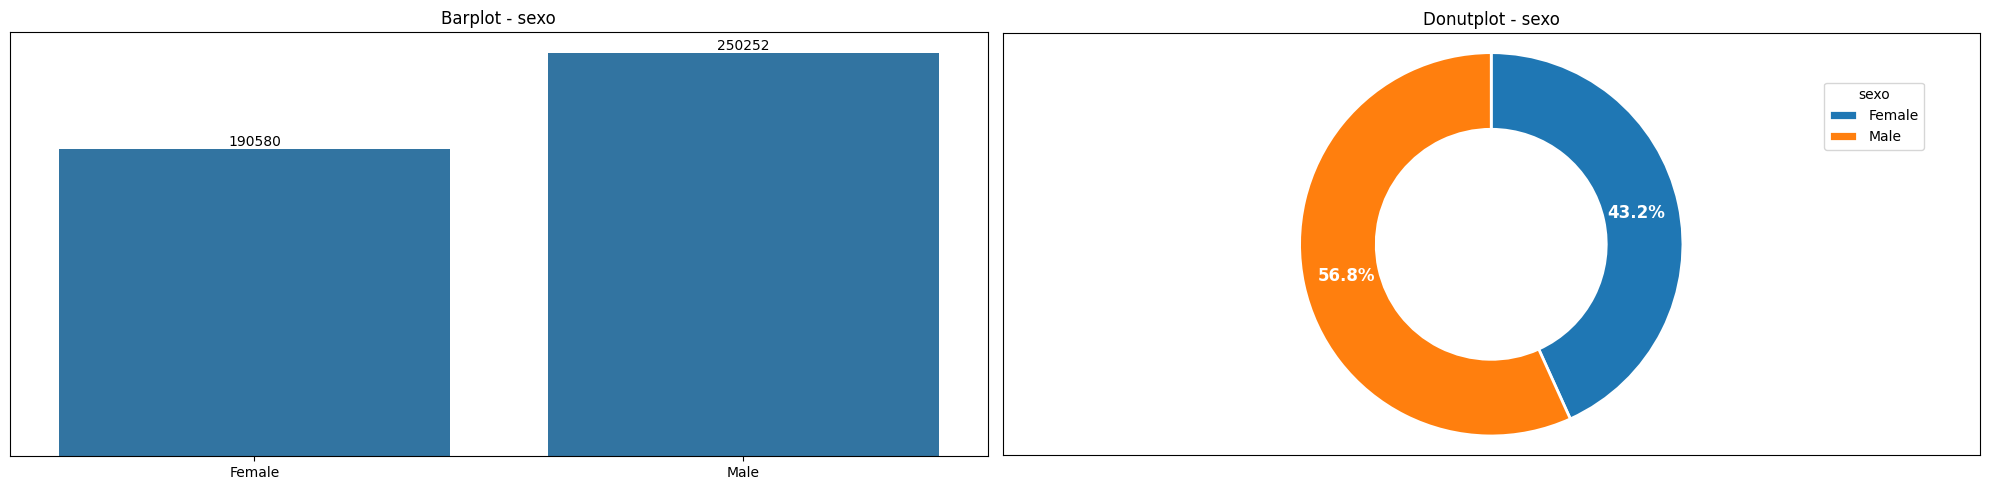

- Agrupamento da coluna: assinatura


assinatura,Percentage,Count
Basic,32.4,143026
Premium,33.7,148678
Standard,33.8,149128


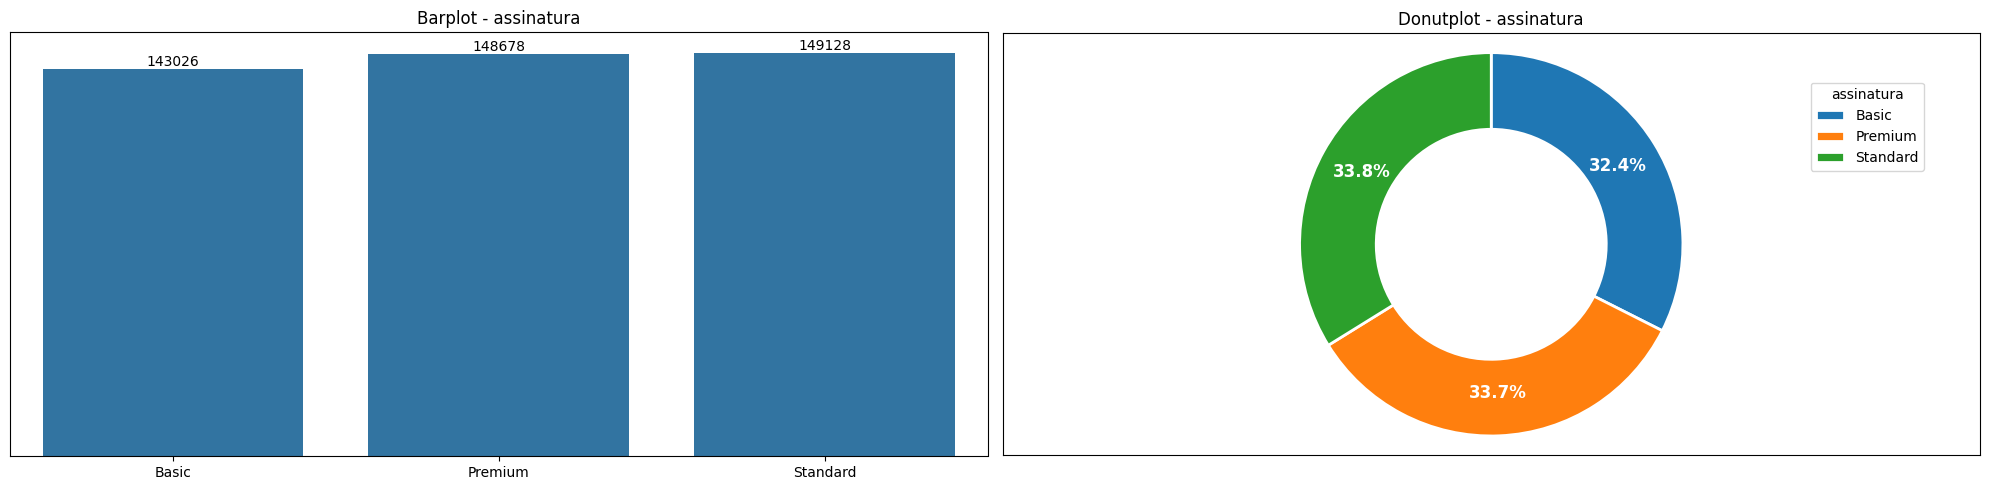

- Agrupamento da coluna: duracao_contrato


duracao_contrato,Percentage,Count
Annual,40.2,177198
Monthly,19.8,87104
Quarterly,40.0,176530


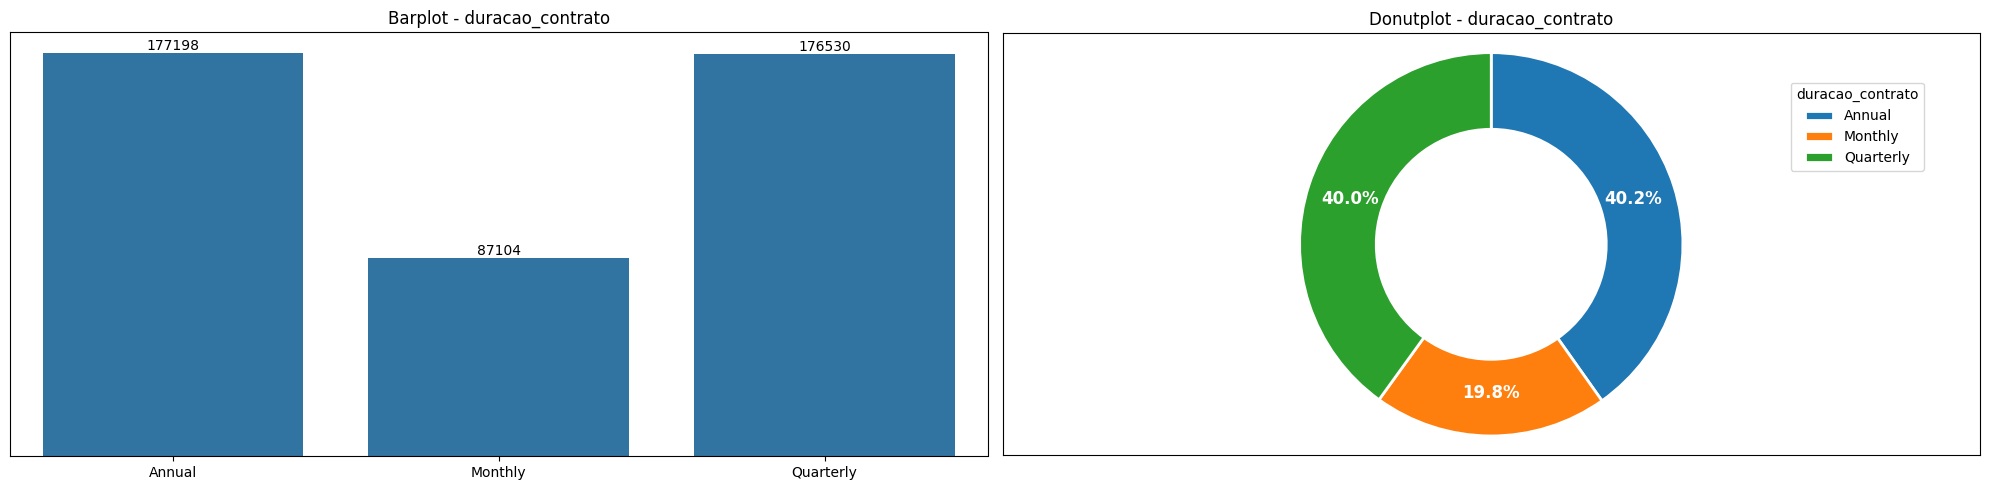

- Agrupamento da coluna: cancelou


cancelou,Percentage,Count
0.0,43.3,190833
1.0,56.7,249999


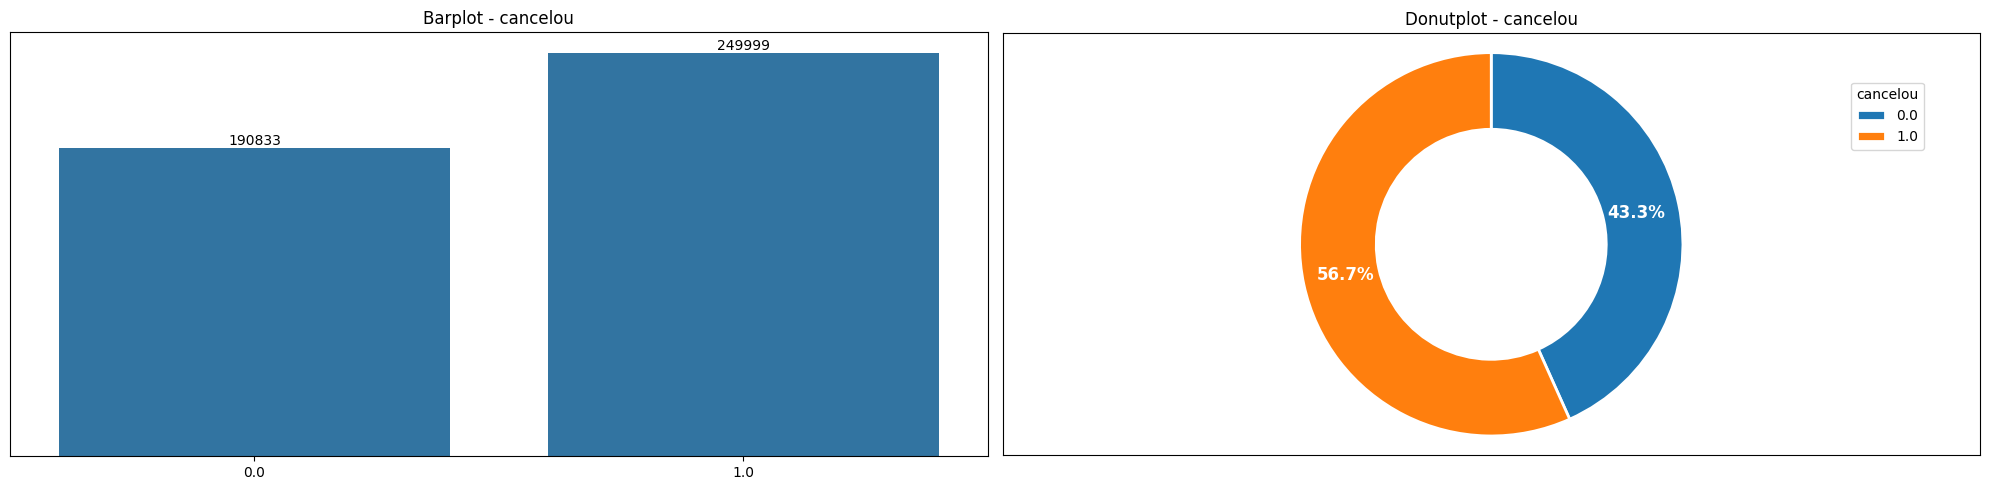

In [15]:
columns = ['sexo', 'assinatura', 'duracao_contrato', 'cancelou']

for i in columns:

    df_agg = fn_stats_pandas.groupby_count(df, i)

    print(f'- Agrupamento da coluna: {i}')

    display(HTML(df_agg.to_html(index = False)))

    df_agg.to_csv(f'../data/04_gold/agg_{i.lower()}_pandas.csv', index = False)

    fn_charts_pandas.barplot_donutplot(df_agg, i, 'Count')

    plt.savefig(f'../images/outputs/charts/pandas/nb05_barplot_donutplot_{i.lower()}.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

    plt.show()